#  Villa Location — Pipeline 


##  Imports

In [1]:
import os, sys, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from datetime import datetime
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

PIPELINE_DIR = os.path.abspath("../../pipeline")
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

RAW_PATH   = "../../data/marrakech_immo_location/villa_location.csv"
CLEAN_PATH = "../../data/cleaned_data/location/villa_location_final.csv"
MODEL_PATH = "../../model_training/models/xgb_villa_location.pkl"
META_PATH  = "../../model_training/models/xgb_villa_location_metadata.json"
print(" Imports OK")


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports OK


## 1. Chargement & Cleaning

In [2]:
from locations.pip_villa import (
    load_data, split_and_encode, build_pipeline, train,
    evaluate, plot_results, predict_price,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG
)

df = load_data(RAW_PATH)
print(f"\nLocalisation_fine (top 15) :")
print(df["localisation_fine"].value_counts().head(15))
print(f"\ncat_surface :")
print(df["cat_surface"].value_counts())


Brut : (1996, 34)
Après dédup contenu : (1850, 34)
EUR → MAD : 31 lignes
 Shape finale : (1383, 55)
   Prix médian  : 30,000 MAD
   Zones        : 25

Localisation_fine (top 15) :
localisation_fine
autre_zone             200
marrakech              106
hay targa              106
targa                  104
route de l'ourika       99
route de ouarzazate     95
agdal                   87
route d'ourika          71
amelkis                 60
route de tahanaout      55
route de fez            54
route de tahanaoute     47
ennakhil palmeraie      43
route de fès            41
route casablanca        38
Name: count, dtype: int64

cat_surface :
cat_surface
medium    428
small     401
tiny      207
large     197
xlarge    115
estate     35
Name: count, dtype: int64


## 2. EDA

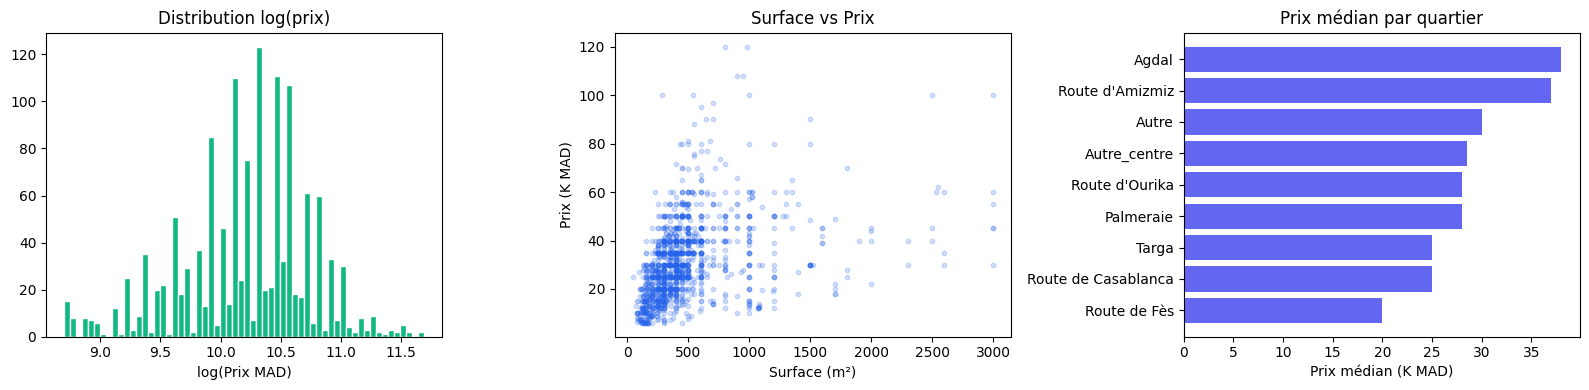


=== Corrélation features → log(prix) ===
salles_bain_num        0.448
chambres_num           0.399
surface_num            0.360
text_standing_score    0.325
kw_standing            0.237
kw_architecte          0.171
score_standing         0.116
nb_equipements         0.024
Name: log_prix, dtype: float64

=== Prix médian par quartier ===
                      median  count
quartier_clean                     
Agdal                38000.0     87
Route d'Amizmiz      37000.0     40
Autre                30000.0    701
Autre_centre         28500.0      4
Palmeraie            28000.0     73
Route d'Ourika       28000.0    180
Route de Casablanca  25000.0     30
Targa                25000.0    211
Route de Fès         20000.0     57


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0].set_title("Distribution log(prix)"); axes[0].set_xlabel("log(Prix MAD)")

axes[1].scatter(df["surface_num"], df["prix_num"]/1e3, alpha=0.2, s=10, color="#2563EB")
axes[1].set_xlabel("Surface (m²)"); axes[1].set_ylabel("Prix (K MAD)")
axes[1].set_title("Surface vs Prix")

med = df.groupby("quartier_clean")["prix_num"].median().sort_values(ascending=True)/1e3
axes[2].barh(med.index, med.values, color="#6366F1")
axes[2].set_xlabel("Prix médian (K MAD)"); axes[2].set_title("Prix médian par quartier")

plt.tight_layout(); plt.show()

print("\n=== Corrélation features → log(prix) ===")
num_check = ["surface_num","chambres_num","salles_bain_num","score_standing",
             "nb_equipements","text_standing_score","kw_standing","kw_architecte"]
print(df[num_check + ["log_prix"]].corr()["log_prix"].drop("log_prix")
      .sort_values(ascending=False).round(3))

print("\n=== Prix médian par quartier ===")
print(df.groupby("quartier_clean")["prix_num"]
      .agg(["median","count"]).sort_values("median",ascending=False).round(0))


## 3. Split + Groupby sans leakage

In [4]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"\nFeatures ({len(NUMERIC_FEATURES+BINARY_FEATURES+CATEGORICAL_FEATURES)}) :")
print(f"  Numériques   ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES[:5]}...")
print(f"  Binaires     ({len(BINARY_FEATURES)}) : {BINARY_FEATURES[:5]}...")
print(f"  Catégoriels  ({len(CATEGORICAL_FEATURES)}) : {CATEGORICAL_FEATURES}")


 Split — Train : 1106 | Test : 277 | Features : 46

Features (46) :
  Numériques   (29) : ['surface_num', 'log_surface', 'surface_par_chambre', 'ratio_ch_surface', 'chambres_num']...
  Binaires     (13) : ['piscine', 'parking', 'ascenseur', 'terrasse', 'jardin']...
  Catégoriels  (4) : ['quartier_clean', 'localisation_fine', 'cat_surface', 'segment_prix']


## 4. Baseline

In [5]:
pipeline_baseline = build_pipeline(X_train)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, X_train, y_train)


 Pipeline — num:29 bin:13 cat:4
Entraînement terminé (cible = log prix)

═════════════════════════════════════════════
  MÉTRIQUES — VILLA LOCATION v2
═════════════════════════════════════════════
  MAE              :           3,939 MAD
  RMSE             :           5,307 MAD
  R²               :          0.8770
  MAPE             :          14.07 %
  CV R² (5 folds)  : 0.8807 ± 0.0099
═════════════════════════════════════════════


## 5. Optuna — 150 trials



In [6]:
num_cols = [c for c in NUMERIC_FEATURES    if c in X_train.columns]
bin_cols = [c for c in BINARY_FEATURES     if c in X_train.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                              num_cols),
    ("bin", "passthrough",                                                 bin_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),   cat_cols),
], remainder="drop")
preprocessor.fit(X_train)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 500, 3000),
        learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        max_depth         = trial.suggest_int("max_depth", 3, 8),
        max_leaves        = trial.suggest_int("max_leaves", 8, 63),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 3, 15),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        gamma             = trial.suggest_float("gamma", 0, 5),
        tree_method       = "hist",
    )
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**params, random_state=42, n_jobs=-1)),
    ])
    # CV sur X_TRAIN — pas X_test
    return cross_val_score(
        pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1
    ).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n Meilleur R² CV : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:25s} : {v}")


  0%|          | 0/150 [00:00<?, ?it/s]

Best trial: 62. Best value: 0.884329: 100%|██████████| 150/150 [02:21<00:00,  1.06it/s]


 Meilleur R² CV : 0.8843
  n_estimators              : 2800
  learning_rate             : 0.005741729032429579
  max_depth                 : 8
  max_leaves                : 13
  subsample                 : 0.7364947862550204
  colsample_bytree          : 0.9979560214932284
  colsample_bylevel         : 0.8279355982043013
  min_child_weight          : 8
  reg_alpha                 : 0.0017964438186174735
  reg_lambda                : 0.0456613696715407
  gamma                     : 0.15430690400759922


## 6. Modèle final

In [7]:
pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study.best_params, tree_method="hist", random_state=42, n_jobs=-1
    )),
])
pipeline_final.fit(X_train, y_train)
print(" Entraînement terminé")


 Entraînement terminé


## 7. Évaluation

In [8]:
metrics_final = evaluate(pipeline_final, X_test, y_test, X_train, y_train)

print(f"\n=== Gain vs baseline ===")
print(f"  R²   : {metrics_baseline['R²']:.4f} → {metrics_final['R²']:.4f}")
print(f"  MAPE : {metrics_baseline['MAPE (%)']:.2f}% → {metrics_final['MAPE (%)']:.2f}%")



═════════════════════════════════════════════
  MÉTRIQUES — VILLA LOCATION v2
═════════════════════════════════════════════
  MAE              :           3,818 MAD
  RMSE             :           5,277 MAD
  R²               :          0.8783
  MAPE             :          13.72 %
  CV R² (5 folds)  : 0.8865 ± 0.0090
═════════════════════════════════════════════

=== Gain vs baseline ===
  R²   : 0.8770 → 0.8783
  MAPE : 14.07% → 13.72%


## 8. Visualisations

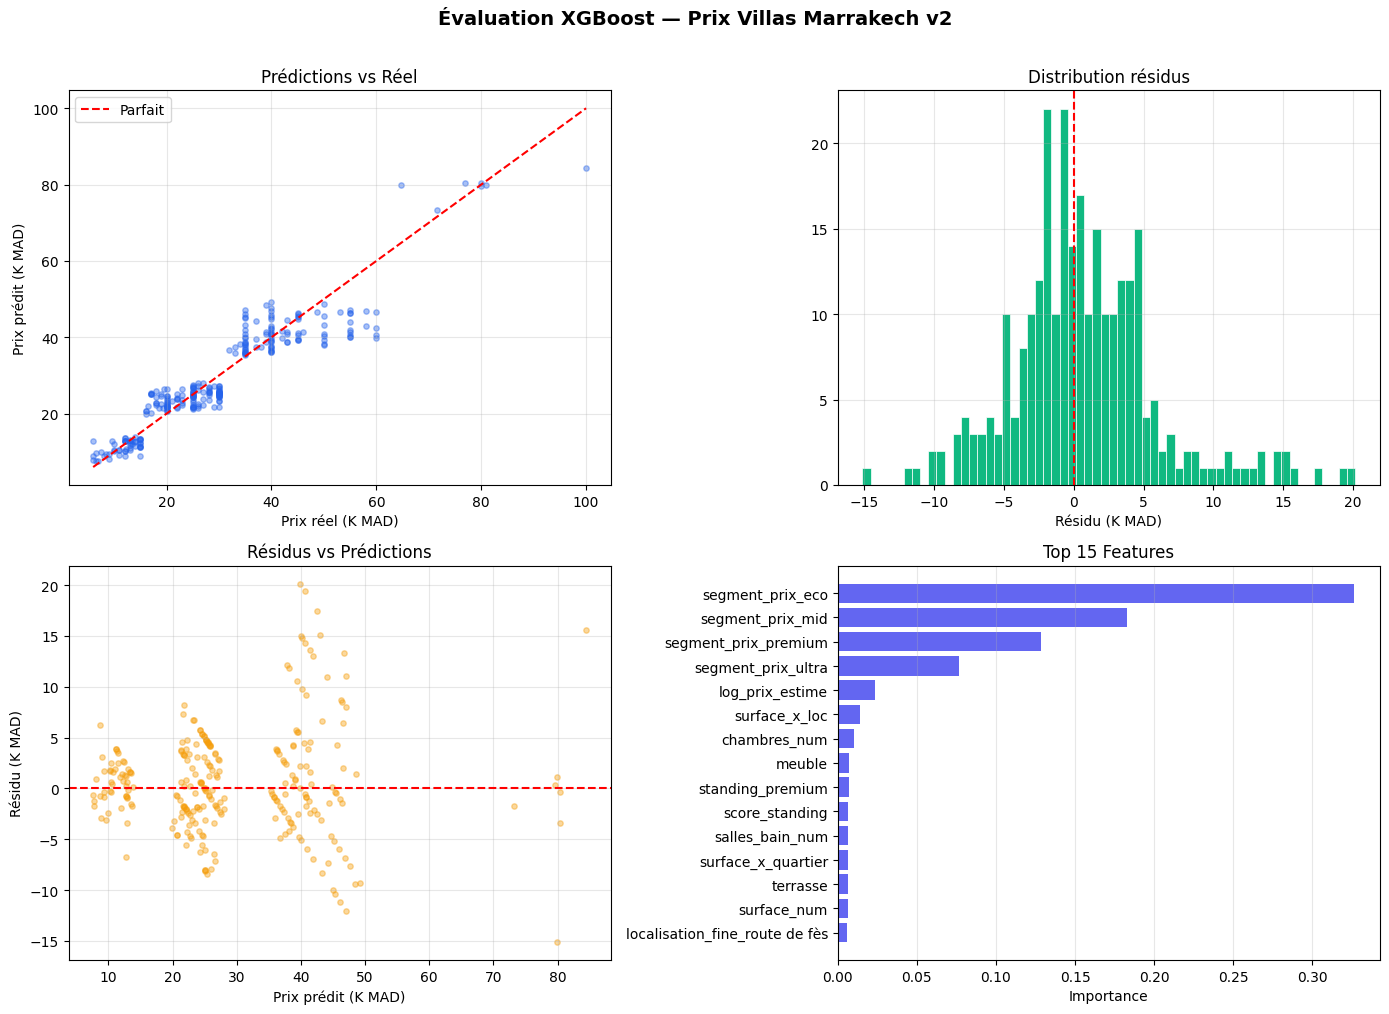

 villa_model_evaluation.png


In [9]:
plot_results(pipeline_final, X_test, y_test)


## 9. Analyse erreurs

In [10]:
y_pred_mad = np.exp(pipeline_final.predict(X_test))
y_true_mad = np.exp(y_test.values)
erreur_pct = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100

df_err = X_test.copy()
df_err["prix_reel"]   = y_true_mad
df_err["prix_predit"] = y_pred_mad
df_err["erreur_pct"]  = erreur_pct

print("=== MAPE par quartier ===")
print(df_err.groupby("quartier_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

print("\n=== MAPE par cat_surface ===")
print(df_err.groupby("cat_surface")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

print("\n=== Précision par seuil ===")
for s in [10, 20, 30, 50]:
    print(f"  Erreur <= {s:2d}% : {(erreur_pct<=s).mean()*100:.1f}% des cas")

print("\n=== Top 10 pires prédictions ===")
df_err["surface"] = df_train.loc[X_test.index.intersection(df_train.index), "surface_num"] if hasattr(df_train, 'loc') else 0
print(df_err.nlargest(10, "erreur_pct")[
    ["quartier_clean","localisation_fine","cat_surface","prix_reel","prix_predit","erreur_pct"]
].to_string())


=== MAPE par quartier ===
                     mean  count
quartier_clean                  
Route de Casablanca  21.2      7
Autre                14.5    141
Route de Fès         14.4     10
Agdal                14.2     13
Targa                13.4     45
Palmeraie            11.8     13
Route d'Ourika       11.3     38
Route d'Amizmiz       9.5     10

=== MAPE par cat_surface ===
             mean  count
cat_surface             
tiny         16.9     43
estate       15.0      4
small        14.1     84
medium       12.8     91
xlarge       12.5     23
large        11.9     32

=== Précision par seuil ===
  Erreur <= 10% : 45.1% des cas
  Erreur <= 20% : 79.4% des cas
  Erreur <= 30% : 92.8% des cas
  Erreur <= 50% : 99.6% des cas

=== Top 10 pires prédictions ===
           quartier_clean    localisation_fine cat_surface  prix_reel   prix_predit  erreur_pct
1145                Autre        route amezmiz       small     6000.0  12702.456055  111.707601
1558                Targa      

In [11]:
# ── Diagnostic features ─────────────────────────────────────
import numpy as np
import pandas as pd

xgb_model = pipeline_final.named_steps["model"]
preproc   = pipeline_final.named_steps["preprocessor"]

try:
    num_bin_cols = list(preproc.transformers_[0][2]) + list(preproc.transformers_[1][2])
    cat_cols_enc = list(preproc.named_transformers_["cat"].get_feature_names_out(
                        preproc.transformers_[2][2]))
    feat_names = num_bin_cols + cat_cols_enc
except:
    feat_names = [f"f{i}" for i in range(xgb_model.n_features_in_)]

importances = xgb_model.feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

print("=== Top 20 importances ===")
print(imp_df.head(20).to_string(index=False))

print("\n=== Nouvelles features — importance ===")
new_feats = ["log_surface","surf_x_piscine","surf_x_standing",
             "te_log_prix_quartier","te_log_prix_loc",
             "pm2_moy_quartier","pm2_median_loc"]
for f in new_feats:
    row = imp_df[imp_df["feature"] == f]
    imp = row["importance"].values[0] if len(row) else 0
    rank = imp_df[imp_df["feature"] == f].index[0] if len(row) else -1
    print(f"  {f:30s} imp={imp:.4f}")

# Corrélation nouvelles features → log_prix
print("\n=== Corrélation → log_prix (train) ===")
new_cols = [c for c in new_feats if c in X_train.columns]
corr = X_train[new_cols].corrwith(y_train).sort_values(ascending=False)
print(corr.round(3))

# Distribution target encoding
print("\n=== te_log_prix_quartier — distribution ===")
print(X_train["te_log_prix_quartier"].describe().round(3))
print(f"  NaN : {X_train['te_log_prix_quartier'].isna().sum()}")

# R² par quartier
y_pred = pipeline_final.predict(X_test)
df_diag = X_test.copy()
df_diag["y_true"] = y_test.values
df_diag["y_pred"] = y_pred
df_diag["residu"] = df_diag["y_true"] - df_diag["y_pred"]
print("\n=== Résidu moyen log_prix par quartier ===")
print(df_diag.groupby("quartier_clean")["residu"]
      .agg(["mean","std","count"]).round(3)
      .sort_values("mean", ascending=False))

=== Top 20 importances ===
                       feature  importance
              segment_prix_eco    0.326538
              segment_prix_mid    0.182880
          segment_prix_premium    0.128560
            segment_prix_ultra    0.076630
               log_prix_estime    0.023425
                 surface_x_loc    0.014155
                  chambres_num    0.010115
                        meuble    0.006936
              standing_premium    0.006868
                score_standing    0.006594
               salles_bain_num    0.006328
            surface_x_quartier    0.006221
                      terrasse    0.006207
                   surface_num    0.006195
localisation_fine_route de fès    0.005653
 quartier_clean_Route d'Ourika    0.005475
                surf_x_piscine    0.005309
           surface_par_chambre    0.005185
              ratio_ch_surface    0.005123
              surface_relative    0.005111

=== Nouvelles features — importance ===
  log_surface                

In [12]:
# ── Diagnostic plafond villa ─────────────────────────────────
import numpy as np
import pandas as pd

y_pred = pipeline_final.predict(X_test)
prix_pred = np.exp(y_pred)
prix_reel = np.exp(y_test.values)
erreur_pct = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_diag = df_test.copy()
df_diag["erreur_pct"] = erreur_pct
df_diag["prix_pred"]  = prix_pred

# 1. Erreur par surface (tranches fines)
df_diag["surf_bin"] = pd.cut(df_diag["surface_num"],
    bins=[0,150,250,350,500,700,1000,9999],
    labels=["<150","150-250","250-350","350-500","500-700","700-1000",">1000"])
print("=== MAPE par tranche surface ===")
print(df_diag.groupby("surf_bin", observed=True)["erreur_pct"]
      .agg(["mean","count"]).round(1))

# 2. Erreur par tranche prix réel
df_diag["prix_bin"] = pd.cut(df_diag["prix_num"]/1e3,
    bins=[0,2,3,5,8,15,100],
    labels=["<2M","2-3M","3-5M","5-8M","8-15M",">15M"])
print("\n=== MAPE par tranche prix ===")
print(df_diag.groupby("prix_bin", observed=True)["erreur_pct"]
      .agg(["mean","count"]).round(1))

# 3. Corrélation résidu avec features — qu'est-ce qui reste non expliqué ?
df_diag["residu_log"] = y_test.values - y_pred
num_feats = [c for c in X_test.columns if X_test[c].dtype in [np.float64, np.int64]]
corr = X_test[num_feats].corrwith(pd.Series(df_diag["residu_log"].values,
                                             index=X_test.index))
print("\n=== Top corrélations résidu ~ features ===")
print(corr.abs().sort_values(ascending=False).head(15).round(3))

# 4. Combien de villas "Autre" ont une localisation_fine connue ?
autre_mask = df_test["quartier_clean"] == "Autre"
print(f"\n=== Villas 'Autre' ({autre_mask.sum()}) ===")
print(f"  localisation_fine != 'autre_zone' : "
      f"{(df_test.loc[autre_mask,'localisation_fine'] != 'autre_zone').sum()}")
print("  Top localisations fines :")
print(df_test.loc[autre_mask,"localisation_fine"].value_counts().head(10))

# 5. Variance intra-zone (log_prix) — plafond théorique par zone
print("\n=== Variance log_prix par quartier (std) ===")
print(df_train.groupby("quartier_clean")["log_prix"]
      .agg(["std","count"]).sort_values("std", ascending=False).round(3))

=== MAPE par tranche surface ===
          mean  count
surf_bin             
<150      18.8     22
150-250   14.6     39
250-350   14.0     66
350-500   12.8     91
500-700   11.8     28
700-1000  13.8     14
>1000     11.9     17

=== MAPE par tranche prix ===
          mean  count
prix_bin             
5-8M      38.2      8
8-15M     13.0     43
>15M      13.0    226

=== Top corrélations résidu ~ features ===
standing_premium    0.154
nb_equipements      0.146
score_standing      0.144
score_exterieur     0.143
surf_x_standing     0.125
piscine             0.119
terrasse            0.119
vue                 0.117
surf_x_piscine      0.108
meuble              0.097
chambres_num        0.090
jardin              0.083
kw_jardin           0.073
pm2_median_loc      0.071
surface_rel_loc     0.071
dtype: float64

=== Villas 'Autre' (141) ===
  localisation_fine != 'autre_zone' : 102
  Top localisations fines :
localisation_fine
autre_zone                    39
marrakech                   

## 10. Sauvegarde

In [13]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

# stats nécessaires pour predict_price()
joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f" Modèle sauvegardé       → {MODEL_PATH}")

metadata = {
    "date"           : datetime.now().strftime("%Y-%m-%d"),
    "version"        : "v2_optuna",
    "modele"         : "XGBRegressor",
    "type_bien"      : "villa_vente",
    "target"         : "log(prix_total)",
    "corrections_v2" : [
        "Suppression category_encoders (leakage)",
        "Suppression surface_terrain_text (3% coverage)",
        "Groupby features calculées sur train uniquement",
        "CV sur X_train (pas X_test)",
    ],
    "n_lignes_train" : len(X_train),
    "n_lignes_test"  : len(X_test),
    "n_features"     : X_train.shape[1],
    "metriques_baseline": {
        "R2"  : round(metrics_baseline["R²"], 4),
        "MAPE": round(metrics_baseline["MAPE (%)"], 2),
    },
    "metriques_test" : {
        "R2"   : round(metrics_final["R²"], 4),
        "MAE"  : round(metrics_final["MAE (MAD)"], 0),
        "RMSE" : round(metrics_final["RMSE (MAD)"], 0),
        "MAPE" : round(metrics_final["MAPE (%)"], 2),
    },
    "cv_r2_optuna"   : round(study.best_value, 4),
    "hyperparametres": study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f" Métadonnées sauvegardées → {META_PATH}")

df.to_csv(CLEAN_PATH, index=False)
print(f" Dataset sauvegardé      → {CLEAN_PATH}")

print("\n" + "═"*50)
print("  RÉSUMÉ FINAL — VILLA LOCATION v2")
print("═"*50)
print(f"  Données          : {len(df):,} villas")
print(f"  Features         : {X_train.shape[1]}")
print(f"  R² baseline      : {metrics_baseline['R²']:.4f}")
print(f"  R² final         : {metrics_final['R²']:.4f}")
print(f"  MAE              : {metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  MAPE             : {metrics_final['MAPE (%)']:.2f} %")
print(f"  CV R² Optuna     : {study.best_value:.4f}")
print("═"*50)


 Modèle sauvegardé       → ../../model_training/models/xgb_villa_location.pkl
 Métadonnées sauvegardées → ../../model_training/models/xgb_villa_location_metadata.json
 Dataset sauvegardé      → ../../data/cleaned_data/location/villa_location_final.csv

══════════════════════════════════════════════════
  RÉSUMÉ FINAL — VILLA LOCATION v2
══════════════════════════════════════════════════
  Données          : 1,383 villas
  Features         : 46
  R² baseline      : 0.8770
  R² final         : 0.8783
  MAE              : 3,818 MAD
  MAPE             : 13.72 %
  CV R² Optuna     : 0.8843
══════════════════════════════════════════════════


## 11. Exemple de prédiction

In [14]:
saved           = joblib.load(MODEL_PATH)
pipeline_loaded = saved["pipeline"]
stats_loaded    = saved["stats"]

villa_exemple = {
    "surface_num"      : 450,
    "chambres_num"     : 5,
    "salles_bain_num"  : 3,
    "etage"            : 0,
    "etage_known"      : 1,
    "quartier_clean"   : "Palmeraie",
    "localisation_fine": "palmeraie",
    "cat_surface"      : "large",
    "piscine"    : 1, "parking"       : 1, "ascenseur" : 0,
    "terrasse"   : 1, "jardin"         : 1, "climatisation": 1,
    "securite"   : 1, "vue"            : 0, "meuble"    : 0,
    "neuf"       : 0, "cave"           : 0, "hammam"    : 1,
    "kw_standing": 1, "kw_renove"      : 0, "kw_architecte": 0,
    "kw_jardin"  : 1, "kw_projet"      : 0,
}

prix = predict_price(pipeline_loaded, villa_exemple, stats_loaded)
fourchette_min = prix * 0.75
fourchette_max = prix * 1.25
print(f"\n  Fourchette ±25% : {fourchette_min:,.0f} – {fourchette_max:,.0f} MAD")


 Villa 450 m² | Palmeraie | Prix estimé : 24,704 MAD (2,287 EUR)
   ≈ 55 MAD/m²

  Fourchette ±25% : 18,528 – 30,880 MAD
